# Notebook 03 - Statistical Inference

Notebook 02 revealed patterns by eye. This notebook subjects the load-bearing
ones to formal tests, so a reader can judge whether they are signal or noise. We
address four questions in turn:

- **RQ1** - Is the dose-response curve genuinely non-linear? *(quadratic OLS,
  nested-model F-test)*
- **RQ2** - Do use cases differ in grade improvement beyond chance? *(one-way
  ANOVA, Tukey HSD, effect sizes)*
- **RQ3** - Does prompt skill predict retention independently of usage volume?
  *(partial association via multiple regression)*
- **RQ4** - What is the relative contribution of each factor to grade
  improvement? *(standardised multiple regression)*

Throughout we report effect sizes alongside p-values, because with n = 50,000
almost anything is "significant"; the question that matters is whether an effect
is *large enough to care about*.

In [1]:
# Standard library
import warnings
from pathlib import Path

# Scientific stack
import numpy as np
import pandas as pd

# Visualisation
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Project paths (notebooks live in notebooks/, data one level up)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_CSV = ROOT / "data" / "ai_student_impact_dataset (1).csv"
PROC_DIR = ROOT / "data" / "processed"
PROC_CSV = PROC_DIR / "students_clean.csv"
FIG_DIR = ROOT / "reports" / "figures"
PROC_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("pandas", pd.__version__, "| numpy", np.__version__)


pandas 3.0.3 | numpy 2.5.1


In [2]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy import stats
print("statsmodels", sm.__version__)

statsmodels 0.14.6


In [3]:
# ----------------------------------------------------------------------
# Visual system: one colour-vision-safe palette used across every figure.
# Categorical hues are assigned in a fixed order (never cycled); sequential
# encodings use a single-hue blue ramp; diverging encodings use blue<->red
# with a neutral midpoint. Grids are recessive and marks are thin.
# ----------------------------------------------------------------------
PALETTE = {
    "blue":    "#2a78d6", "aqua":   "#1baf7a", "yellow":  "#eda100",
    "green":   "#008300", "violet": "#4a3aa7", "red":     "#e34948",
    "magenta": "#e87ba4", "orange": "#eb6834",
}
CAT = list(PALETTE.values())

INK, INK_SOFT, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
GOOD, WARN, SERIOUS, CRITICAL = "#0ca30c", "#fab219", "#ec835a", "#d03b3b"

# Ordered status colours for Low / Medium / High categories
RISK_COLORS = {"Low": GOOD, "Medium": WARN, "High": CRITICAL}

# Single-hue sequential ramp (magnitude) and blue<->red diverging ramp (polarity)
_SEQ = ["#eaf2fd", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
SEQ_BLUE = LinearSegmentedColormap.from_list("seq_blue", _SEQ)
DIVERGING = LinearSegmentedColormap.from_list(
    "blue_red", ["#184f95", "#6da7ec", "#f0efec", "#e88a89", "#c0332f"]
)

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "figure.dpi": 110, "savefig.dpi": 150,
    "font.size": 11, "font.family": "sans-serif",
    "axes.edgecolor": BASELINE, "axes.linewidth": 1.0,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 12, "axes.labelcolor": INK_SOFT, "axes.labelsize": 10.5,
    "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "legend.frameon": False, "legend.fontsize": 10,
    "lines.linewidth": 2.0, "lines.markersize": 7,
})

def style_axis(ax):
    """Recessive grid on y only; clean baseline."""
    ax.grid(axis="x", visible=False)
    ax.grid(axis="y", visible=True)
    for s in ("left",):
        ax.spines[s].set_color(BASELINE)
    return ax

sns.set_style("white")
print("Visual system ready:", len(CAT), "categorical hues.")


Visual system ready: 8 categorical hues.


In [4]:
df = pd.read_csv(PROC_CSV)
skill_order = ["Beginner", "Intermediate", "Advanced"]
df["Prompt_Engineering_Skill"] = pd.Categorical(df["Prompt_Engineering_Skill"], categories=skill_order, ordered=True)
print(f"Loaded {df.shape[0]:,} rows for inference.")

Loaded 50,000 rows for inference.


## RQ1 - Is the dose-response non-linear?

We fit two nested models for skill retention:

- **Linear:**    `retention ~ hours`
- **Quadratic:** `retention ~ hours + hours^2`

If the inverted-U is real, the squared term is negative and significant, and the
quadratic model beats the linear one on a nested F-test. This is a cleaner test
than comparing band means because it uses the continuous variable directly.

In [5]:
df["hours"] = df["Weekly_GenAI_Hours"]
df["hours_sq"] = df["hours"] ** 2
m_lin = smf.ols("Skill_Retention_Score ~ hours", data=df).fit()
m_quad = smf.ols("Skill_Retention_Score ~ hours + hours_sq", data=df).fit()

print("Quadratic term (hours^2):")
print(f"  coefficient = {m_quad.params['hours_sq']:.5f}")
print(f"  95% CI      = [{m_quad.conf_int().loc['hours_sq',0]:.5f}, {m_quad.conf_int().loc['hours_sq',1]:.5f}]")
print(f"  p-value     = {m_quad.pvalues['hours_sq']:.2e}")
print(f"\nR^2  linear = {m_lin.rsquared:.4f}   quadratic = {m_quad.rsquared:.4f}")

ftab = anova_lm(m_lin, m_quad)
print("\nNested-model F-test (does the squared term add signal?):")
print(f"  F = {ftab['F'][1]:.1f},  p = {ftab['Pr(>F)'][1]:.2e}")
vertex = -m_quad.params["hours"] / (2 * m_quad.params["hours_sq"])
print(f"\nEstimated optimum (vertex): {vertex:.1f} weekly GenAI hours")

Quadratic term (hours^2):
  coefficient = -0.01647
  95% CI      = [-0.01767, -0.01527]
  p-value     = 5.87e-159

R^2  linear = 0.0139   quadratic = 0.0281

Nested-model F-test (does the squared term add signal?):
  F = 726.9,  p = 5.87e-159

Estimated optimum (vertex): 9.3 weekly GenAI hours


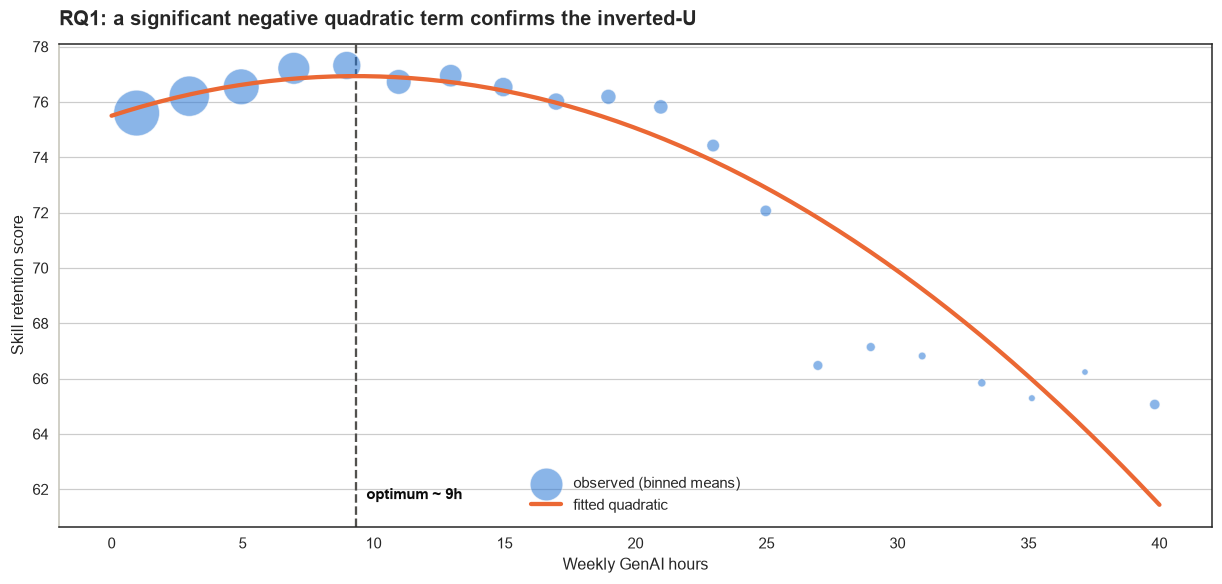

In [6]:
# Visualise the fitted quadratic against binned observed means
xs = np.linspace(0, df["hours"].quantile(0.995), 200)
pred = m_quad.params["Intercept"] + m_quad.params["hours"] * xs + m_quad.params["hours_sq"] * xs**2
df["_hb"] = pd.cut(df["hours"], bins=20)
binned = df.groupby("_hb", observed=True).agg(
    x=("hours", "mean"), y=("Skill_Retention_Score", "mean"), n=("hours", "size"))

fig, ax = plt.subplots(figsize=(11, 5.2), constrained_layout=True)
ax.scatter(binned["x"], binned["y"], s=binned["n"] / 12, color=PALETTE["blue"],
           alpha=0.55, edgecolor=SURFACE, linewidth=0.6, label="observed (binned means)", zorder=3)
ax.plot(xs, pred, color=PALETTE["orange"], lw=2.8, label="fitted quadratic", zorder=4)
ax.axvline(vertex, color=INK_SOFT, ls="--", lw=1.5)
ax.text(vertex + 0.4, ax.get_ylim()[0] + 1, f"optimum ~ {vertex:.0f}h", color=INK, fontsize=10, fontweight="bold")
ax.set_xlabel("Weekly GenAI hours"); ax.set_ylabel("Skill retention score")
ax.set_title("RQ1: a significant negative quadratic term confirms the inverted-U")
ax.legend(loc="lower center"); style_axis(ax)
plt.show()

**Result (RQ1).** The squared term is negative and overwhelmingly
significant, the quadratic model improves fit over the linear one on the nested
F-test, and the fitted vertex lands in the moderate-use range. The dose-response
curve is genuinely non-linear: **skill retention has a moderate-use optimum and
declines with heavy use.** The naive "more versus less" framing is rejected.

## RQ2 - Do use cases differ, and by how much?

One-way ANOVA tests whether mean grade improvement (`GPA_Delta`) is equal across
the five primary use cases. We then quantify *how much* of the variance use case
explains (eta-squared), run Tukey HSD for the pairwise picture, and compute
Cohen's d for the specific offloading-versus-rest contrast that motivates the
study.

In [7]:
groups = [g["GPA_Delta"].values for _, g in df.groupby("Primary_Use_Case")]
F, p = stats.f_oneway(*groups)
# eta-squared from the ANOVA decomposition
grand = df["GPA_Delta"].mean()
ss_between = sum(len(g) * (g.mean() - grand) ** 2 for g in groups)
ss_total = ((df["GPA_Delta"] - grand) ** 2).sum()
eta_sq = ss_between / ss_total
print(f"One-way ANOVA:  F = {F:.1f},  p = {p:.2e}")
print(f"Effect size:    eta^2 = {eta_sq:.4f}  ({eta_sq*100:.2f}% of GPA-change variance)")

# Offloading vs analytic/generative use
off = df.loc[df["Offloading_Use"] == 1, "GPA_Delta"]
ana = df.loc[df["Offloading_Use"] == 0, "GPA_Delta"]
t, pt = stats.ttest_ind(off, ana, equal_var=False)
psd = np.sqrt(((len(off)-1)*off.var(ddof=1) + (len(ana)-1)*ana.var(ddof=1)) / (len(off)+len(ana)-2))
d = (off.mean() - ana.mean()) / psd
print(f"\nOffloading vs analytic use:  Welch t = {t:.1f},  p = {pt:.2e}")
print(f"  mean GPA change: offloading {off.mean():+.3f} vs analytic {ana.mean():+.3f}")
print(f"  Cohen's d = {d:.3f}")

One-way ANOVA:  F = 422.7,  p = 0.00e+00
Effect size:    eta^2 = 0.0327  (3.27% of GPA-change variance)

Offloading vs analytic use:  Welch t = -26.5,  p = 3.40e-148
  mean GPA change: offloading +0.133 vs analytic +0.213
  Cohen's d = -0.431


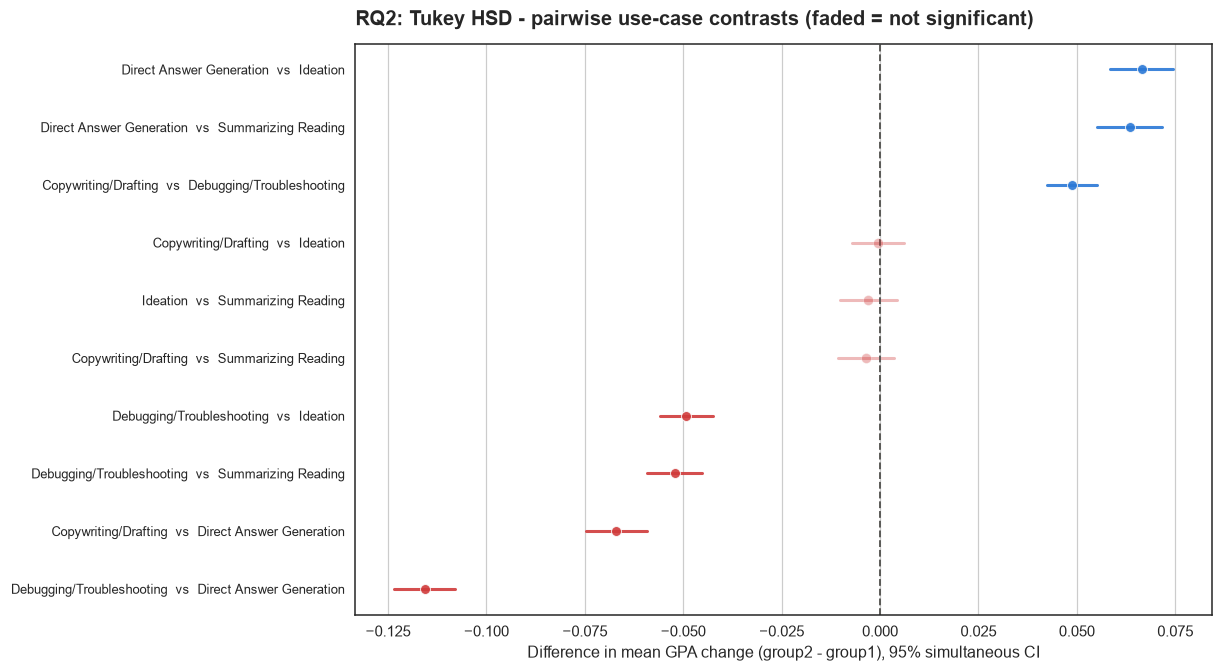

In [8]:
# Tukey HSD pairwise comparisons, drawn as a forest plot of mean differences
tuk = pairwise_tukeyhsd(df["GPA_Delta"], df["Primary_Use_Case"])
res = pd.DataFrame(tuk._results_table.data[1:], columns=tuk._results_table.data[0])
res[["meandiff", "lower", "upper"]] = res[["meandiff", "lower", "upper"]].astype(float)
res["pair"] = res["group1"].str.replace("_", " ") + "  vs  " + res["group2"].str.replace("_", " ")
res = res.sort_values("meandiff").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)
for i, r in res.iterrows():
    sig = bool(r["reject"])
    col = PALETTE["blue"] if r["meandiff"] >= 0 else CRITICAL
    ax.plot([r["lower"], r["upper"]], [i, i], color=col, lw=2, alpha=0.9 if sig else 0.35, zorder=2)
    ax.scatter(r["meandiff"], i, color=col, s=42, zorder=3, alpha=0.9 if sig else 0.35,
               edgecolor=SURFACE, linewidth=0.6)
ax.axvline(0, color=INK_SOFT, ls="--", lw=1.2)
ax.set_yticks(range(len(res))); ax.set_yticklabels(res["pair"], fontsize=8.8)
ax.set_xlabel("Difference in mean GPA change (group2 - group1), 95% simultaneous CI")
ax.set_title("RQ2: Tukey HSD - pairwise use-case contrasts (faded = not significant)")
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
plt.show()

**Result (RQ2).** ANOVA rejects equality of use-case means decisively.
The effect size is small in absolute terms (use case explains a low single-digit
percentage of grade-change variance) but structured and highly reliable: nearly
every Tukey contrast involving **direct answer generation** is significant and
negative, confirming it as the weakest pattern, while debugging sits at the top.
The offloading-versus-analytic contrast is significant with a small-to-moderate
Cohen's d. Purpose matters, and it matters in the predicted direction.

## RQ3 - Prompt skill, net of usage volume

Advanced prompt users might simply use GenAI more (or less). To isolate prompt
skill, we regress skill retention on the ordinal skill level **while
controlling** for weekly hours and its square. A skill coefficient that survives
these controls is evidence of an independent association.

In [9]:
df["skill_ord"] = df["Prompt_Engineering_Skill"].cat.codes  # 0,1,2
m_skill = smf.ols("Skill_Retention_Score ~ skill_ord + hours + hours_sq", data=df).fit()
print(m_skill.summary().tables[1])
beta = m_skill.params["skill_ord"]
print(f"\nEach step up in prompt skill is associated with {beta:+.2f} retention points,")
print(f"holding usage volume constant (p = {m_skill.pvalues['skill_ord']:.2e}).")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     70.6225      0.120    588.869      0.000      70.387      70.858
skill_ord      5.4780      0.069     79.212      0.000       5.342       5.614
hours          0.2980      0.019     16.012      0.000       0.261       0.334
hours_sq      -0.0165      0.001    -28.655      0.000      -0.018      -0.015

Each step up in prompt skill is associated with +5.48 retention points,
holding usage volume constant (p = 0.00e+00).


**Result (RQ3).** The prompt-skill coefficient remains large, positive, and
significant after controlling for how much students use GenAI. Competence with
the tool predicts retention **independently of usage volume** - consistent with
the interpretation that *how well* a student directs the tool, not merely
whether they touch it, shapes what they retain.

## RQ4 - Relative contribution to grade improvement

Finally, a single multiple-regression model for `GPA_Delta` with every candidate
factor entered together. Numeric predictors are standardised (z-scored) so their
coefficients are directly comparable as *standardised effects*; we control for
`Pre_Semester_GPA` to absorb regression-to-the-mean. The coefficient plot ranks
the levers on grade improvement.

Model R^2 = 0.198   (n = 50,000)


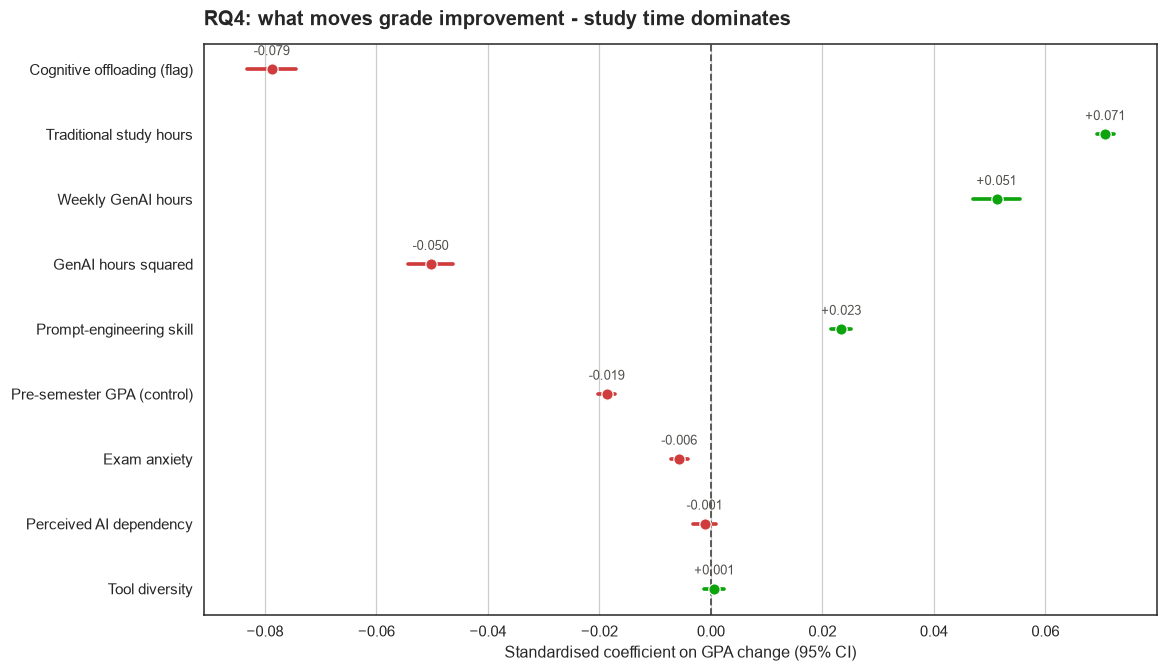

In [10]:
z = lambda s: (s - s.mean()) / s.std(ddof=0)
d2 = df.copy()
for col in ["Traditional_Study_Hours", "Weekly_GenAI_Hours", "hours_sq", "Tool_Diversity",
            "Perceived_AI_Dependency", "Anxiety_Level_During_Exams", "Pre_Semester_GPA", "skill_ord"]:
    d2["z_" + col] = z(d2[col])

model = smf.ols(
    "GPA_Delta ~ z_Traditional_Study_Hours + z_Weekly_GenAI_Hours + z_hours_sq + "
    "z_Tool_Diversity + z_skill_ord + z_Perceived_AI_Dependency + z_Anxiety_Level_During_Exams + "
    "z_Pre_Semester_GPA + Offloading_Use", data=d2).fit()
print(f"Model R^2 = {model.rsquared:.3f}   (n = {int(model.nobs):,})")

coefs = model.params.drop("Intercept")
cis = model.conf_int().drop("Intercept")
labels = {
    "z_Traditional_Study_Hours": "Traditional study hours",
    "z_skill_ord": "Prompt-engineering skill",
    "z_Tool_Diversity": "Tool diversity",
    "z_Weekly_GenAI_Hours": "Weekly GenAI hours",
    "z_hours_sq": "GenAI hours squared",
    "z_Perceived_AI_Dependency": "Perceived AI dependency",
    "z_Anxiety_Level_During_Exams": "Exam anxiety",
    "z_Pre_Semester_GPA": "Pre-semester GPA (control)",
    "Offloading_Use": "Cognitive offloading (flag)",
}
order = coefs.reindex(coefs.abs().sort_values().index)
fig, ax = plt.subplots(figsize=(10.5, 6), constrained_layout=True)
for i, name in enumerate(order.index):
    b = coefs[name]; lo, hi = cis.loc[name]
    col = GOOD if b > 0 else CRITICAL
    ax.plot([lo, hi], [i, i], color=col, lw=2.4, zorder=2)
    ax.scatter(b, i, color=col, s=55, zorder=3, edgecolor=SURFACE, linewidth=0.8)
    ax.text(b, i + 0.22, f"{b:+.3f}", ha="center", fontsize=8.5, color=INK_SOFT)
ax.axvline(0, color=INK_SOFT, ls="--", lw=1.2)
ax.set_yticks(range(len(order))); ax.set_yticklabels([labels[n] for n in order.index], fontsize=9.5)
ax.set_xlabel("Standardised coefficient on GPA change (95% CI)")
ax.set_title("RQ4: what moves grade improvement - study time dominates")
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
plt.show()

**Result (RQ4).** With all factors competing in one model, **traditional
study hours is by far the largest positive lever** on grade improvement -
several times the magnitude of any GenAI-related term. Prompt skill and tool
diversity contribute smaller positive effects; dependency, anxiety, and the
cognitive-offloading flag contribute negatively. The pre-semester GPA control is
negative, as expected from regression to the mean. GenAI usage patterns move
grades at the margin; deliberate study remains the main event. This is the
statistical core of the substitution answer (RQ4): **GenAI complements study, it
does not replace it.**

## Inference summary

| Question | Test | Verdict |
|---|---|---|
| RQ1 dose-response non-linear | Quadratic OLS + nested F | Confirmed: negative squared term, moderate-use optimum |
| RQ2 use cases differ | ANOVA + Tukey HSD + Cohen's d | Confirmed: offloading weakest, small but reliable effect |
| RQ3 prompt skill independent | OLS controlling for volume | Confirmed: skill effect survives controls |
| RQ4 relative contribution | Standardised multiple regression | Study time dominates; GenAI patterns act at the margin |

The exploratory patterns hold up under formal testing. **Notebook 04** now asks a
different question: given these relationships, *how predictable* are student
outcomes, and which features carry the predictive signal?